## FD_abs[hhb2] ANN Fitting

In [1]:
import sys
from google.colab import drive
drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/MCX_data'
sys.path.append(folder_path)

Mounted at /content/drive


In [2]:
import pandas as pd
import glob
import os
import numpy as np
import sys
import pickle
from tqdm import tqdm
! pip install pmcx
from concurrent.futures import ThreadPoolExecutor
#from FDNIRS_dprocesser import load_and_process_all as lapa
from sklearn.preprocessing import StandardScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 100.7 MB/s eta 0:00:00


### Read Simulation data

In [3]:
# -*- coding: utf-8 -*-
# Train an ANN to predict HHB2 from MCX simulation pickles.

import os, re, pickle, math, random
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_FDnirsANN_model(input_dim=192,
                           optimizer=None,
                           loss='mse',
                           metrics=None):
    """
    Constructs and returns the deep MLP regression model.

    Args:
      input_dim (int): size of the input feature vector
      optimizer (str or keras Optimizer): optimizer to use (default: Adam)
      loss (str): loss function (default: 'mse')
      metrics (list): list of metric names (default: ['mae'])

    Returns:
      model: a compiled keras Model instance
    """
    if optimizer is None:
        optimizer = Adam()
    if metrics is None:
        metrics = ['mae']

    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(1000, activation='relu'),
        Dropout(0.1),

        Dense(4096, activation='relu'),
        Dropout(0.1),

        Dense(4096, activation='relu'),
        Dropout(0.2),

        Dense(8192, activation='relu'),
        Dropout(0.2),

        Dense(8192 * 2, activation='relu'),
        Dropout(0.2),

        Dense(8192, activation='relu'),
        Dropout(0.2),

        Dense(4096, activation='relu'),
        Dropout(0.2),

        Dense(2048, activation='relu'),
        Dropout(0.2),

        Dense(1024, activation='relu'),
        Dropout(0.2),

        Dense(512, activation='relu'),
        Dropout(0.1),

        Dense(256, activation='relu'),
        Dropout(0.1),

        Dense(64, activation='relu'),
        Dropout(0.1),

        Dense(32, activation='relu'),
        Dropout(0.0),

        Dense(1)
    ])

    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return model

Found 10000 matching pickles with GT.


Loading (threads):   0%|          | 0/10000 [00:00<?, ?file/s]

Split sizes → train: 8999, val: 501, test: 500
Applied z-score on X and y using TRAIN-only statistics.
  X: mean shape (1, 404), std shape (1, 404)
  y: mean 7.003435, std 2.886264
Epoch 1/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 1.0470 - mae: 0.8873
Epoch 1: val_mae improved from inf to 0.88724, saving model to best_ann_hhb2.h5


282/282 ━━━━━━━━━━━━━━━━━━━━ 85s 258ms/step - loss: 1.0469 - mae: 0.8873 - val_loss: 1.0665 - val_mae: 0.8872 - learning_rate: 1.0000e-04
Epoch 2/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1.0291 - mae: 0.8784
Epoch 2: val_mae did not improve from 0.88724
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - loss: 1.0290 - mae: 0.8783 - val_loss: 1.2234 - val_mae: 0.9363 - learning_rate: 1.0000e-04
Epoch 3/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1.0283 - mae: 0.8776
Epoch 3: val_mae did not improve from 0.88724
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - loss: 1.0282 - mae: 0.8775 - val_loss: 1.0490 - val_mae: 0.8927 - learning_rate: 1.0000e-04
Epoch 4/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1.0274 - mae: 0.8781
Epoch 4: val_mae did not improve from 0.88724
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - loss: 1.0273 - mae: 0.8780 - val_loss: 1.0490 - val_mae: 0.8937 - learning_rate: 1.0000e-04
Epoch 5/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1.

282/282 ━━━━━━━━━━━━━━━━━━━━ 30s 107ms/step - loss: 1.0253 - mae: 0.8775 - val_loss: 1.0655 - val_mae: 0.8840 - learning_rate: 1.0000e-04
Epoch 9/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 1.0158 - mae: 0.8699
Epoch 9: val_mae improved from 0.88403 to 0.87415, saving model to best_ann_hhb2.h5


...

282/282 ━━━━━━━━━━━━━━━━━━━━ 31s 110ms/step - loss: 0.5533 - mae: 0.6017 - val_loss: 0.5998 - val_mae: 0.6552 - learning_rate: 5.0000e-05
Epoch 65/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.5217 - mae: 0.5801
Epoch 65: val_mae improved from 0.65521 to 0.64830, saving model to best_ann_hhb2.h5


282/282 ━━━━━━━━━━━━━━━━━━━━ 32s 112ms/step - loss: 0.5217 - mae: 0.5801 - val_loss: 0.5870 - val_mae: 0.6483 - learning_rate: 5.0000e-05
Epoch 66/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.4996 - mae: 0.5704
Epoch 66: val_mae did not improve from 0.64830
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - loss: 0.4996 - mae: 0.5704 - val_loss: 0.6059 - val_mae: 0.6607 - learning_rate: 5.0000e-05
Epoch 67/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.5110 - mae: 0.5772
Epoch 67: val_mae did not improve from 0.64830
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - loss: 0.5110 - mae: 0.5772 - val_loss: 0.6014 - val_mae: 0.6570 - learning_rate: 5.0000e-05
Epoch 68/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.5208 - mae: 0.5816
Epoch 68: val_mae did not improve from 0.64830
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - loss: 0.5208 - mae: 0.5815 - val_loss: 0.6004 - val_mae: 0.6510 - learning_rate: 5.0000e-05
Epoch 69/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - l

282/282 ━━━━━━━━━━━━━━━━━━━━ 31s 111ms/step - loss: 0.3852 - mae: 0.4906 - val_loss: 0.5994 - val_mae: 0.6470 - learning_rate: 6.2500e-06
Epoch 99/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.3811 - mae: 0.4898
Epoch 99: val_mae did not improve from 0.64699
282/282 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - loss: 0.3811 - mae: 0.4898 - val_loss: 0.5988 - val_mae: 0.6475 - learning_rate: 6.2500e-06
Epoch 100/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.3808 - mae: 0.4862
Epoch 100: val_mae did not improve from 0.64699
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - loss: 0.3808 - mae: 0.4862 - val_loss: 0.6021 - val_mae: 0.6492 - learning_rate: 6.2500e-06
Epoch 101/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.3806 - mae: 0.4900
Epoch 101: val_mae did not improve from 0.64699
282/282 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - loss: 0.3806 - mae: 0.4900 - val_loss: 0.6069 - val_mae: 0.6508 - learning_rate: 6.2500e-06
Epoch 102/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/ste

282/282 ━━━━━━━━━━━━━━━━━━━━ 31s 111ms/step - loss: 0.3762 - mae: 0.4845 - val_loss: 0.5945 - val_mae: 0.6441 - learning_rate: 6.2500e-06
Epoch 104/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.3732 - mae: 0.4806
Epoch 104: val_mae did not improve from 0.64413
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - loss: 0.3732 - mae: 0.4806 - val_loss: 0.6009 - val_mae: 0.6481 - learning_rate: 6.2500e-06
Epoch 105/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.3806 - mae: 0.4892
Epoch 105: val_mae did not improve from 0.64413
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - loss: 0.3806 - mae: 0.4892 - val_loss: 0.6047 - val_mae: 0.6503 - learning_rate: 6.2500e-06
Epoch 106/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.3744 - mae: 0.4816
Epoch 106: val_mae did not improve from 0.64413
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - loss: 0.3744 - mae: 0.4816 - val_loss: 0.6067 - val_mae: 0.6513 - learning_rate: 6.2500e-06
Epoch 107/200
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/s


=== TEST METRICS (best checkpoint; de-normalized ŷ) ===
MAE : 1.668794
RMSE: 2.062743
R^2 : 0.467020
Saved best model → best_ann_hhb2.h5


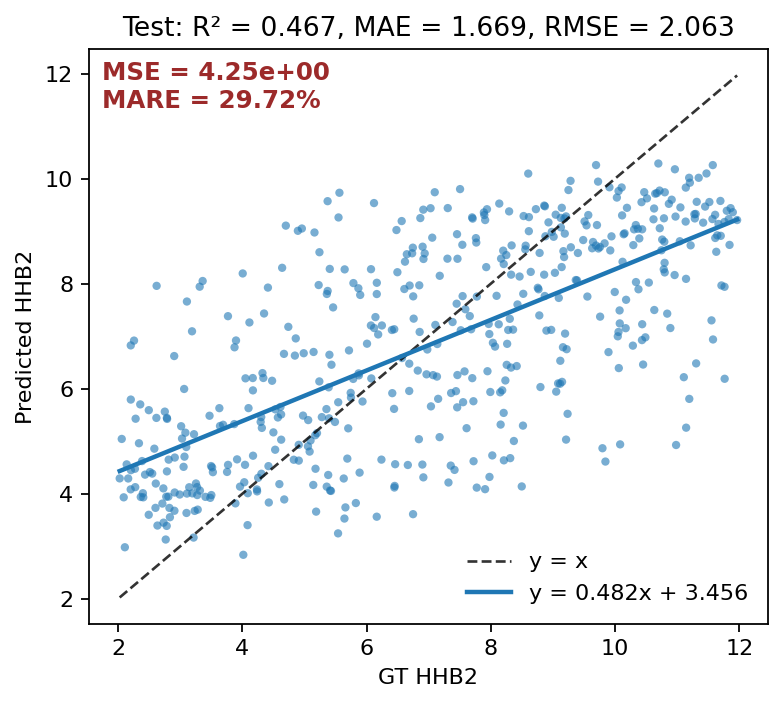

In [5]:
# -*- coding: utf-8 -*-
# Train an ANN to predict HHB2 from MCX simulation pickles (dict {10:[100], 30:[100]}).
# Z-SCORES BOTH X and y using TRAIN-ONLY statistics. Shows a tqdm progress bar while loading.

from pathlib import Path
import os, math, random, pickle
from typing import Any, Tuple

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor

# ---------------------
# Paths / Config
# ---------------------
RESULT_ROOT = Path('/content/drive/MyDrive/MCX_data/result_folder/cw_stage1')   # part1..part20
GT_CSV      = Path('/content/drive/MyDrive/MCX_data/cw_stage1_csv/satge1.csv')  # columns "ID", "HHB2"
# If your CSV file is actually "stage1.csv", fix the path above.

TARGET_COL  = 'CCO2'     # ground truth column
ID_COL      = 'ID'
EACH_LEN    = 101        # length for key=10 and key=30 individually
TARGET_LEN  = 4 * EACH_LEN  # 200 features total after concatenation
TEST_SIZE   = 0.05
VAL_SIZE    = 0.05
SEED        = 1337

BATCH_SIZE  = 32
EPOCHS      = 200
LR          = 1e-4
BEST_MODEL  = 'best_ann_hhb2.h5'

# Data-loading performance
USE_THREADS = True                 # set False for simple sequential load
NUM_WORKERS = min(32, (os.cpu_count() or 8) * 2)

# ---------------------
# Repro & GPU mem growth
# ---------------------
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
for g in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

# ---------------------
# Helpers
# ---------------------
def _as_float1d(x, want_len):
    """Ensure 1D float32; if length mismatches, resample to want_len."""
    a = np.asarray(x, dtype=np.float32).ravel()
    if a.size == want_len:
        return a
    xp = np.linspace(0.0, 1.0, max(1, a.size), dtype=np.float32)
    xnew = np.linspace(0.0, 1.0, want_len, dtype=np.float32)
    return np.interp(xnew, xp, a).astype(np.float32)

def load_pickle_feature(pkl_path: Path, each_len: int = EACH_LEN) -> np.ndarray:
    """
    Each pickle is a dict with keys 10 and 30, each a list/array length ~ each_len.
    Return a 200-D vector: [values_for_key_10 (each_len), values_for_key_30 (each_len)].
    """
    with open(pkl_path, 'rb') as f:
        obj = pickle.load(f)

    def get_key(d, k):
        if k in d: return d[k]
        sk = str(k)
        if sk in d: return d[sk]
        raise KeyError(f"Missing key {k} (/'{sk}') in {pkl_path}")

    v10 = _as_float1d(get_key(obj, 10), each_len)
    v20 = _as_float1d(get_key(obj, 20), each_len)
    v30 = _as_float1d(get_key(obj, 30), each_len)
    v40 = _as_float1d(get_key(obj, 40), each_len)
    feat = np.concatenate([v10, v20, v30, v40], axis=0).astype(np.float32)
    #if feat.size != 2 * each_len:
    #    raise ValueError(f"{pkl_path}: got {feat.size}, expected {2*each_len}")
    return feat

# ---------------------
# Read GT and build ID -> target mapping
# ---------------------
if not GT_CSV.exists():
    raise FileNotFoundError(f"GT CSV not found: {GT_CSV}")

gt_df = pd.read_csv(GT_CSV)
cols_lc = {c.lower(): c for c in gt_df.columns}
if ID_COL.lower() not in cols_lc or TARGET_COL.lower() not in cols_lc:
    raise ValueError(f"CSV must contain '{ID_COL}' and '{TARGET_COL}'. Found: {list(gt_df.columns)}")
ID_COL_REAL = cols_lc[ID_COL.lower()]
TARGET_COL_REAL = cols_lc[TARGET_COL.lower()]

id_to_target = dict(zip(gt_df[ID_COL_REAL].astype(int).tolist(),
                        gt_df[TARGET_COL_REAL].astype(float).tolist()))

# ---------------------
# Scan all folders and gather matching (ID, path)
# ---------------------
if not RESULT_ROOT.exists():
    raise FileNotFoundError(f"RESULT_ROOT not found: {RESULT_ROOT}")

pairs: list[Tuple[int, Path]] = []
for sub in sorted(RESULT_ROOT.glob('part*')):
    if not sub.is_dir():
        continue
    for p in sorted(sub.glob('*.pkl')):
        try:
            pid = int(Path(p).stem)  # expects filenames like "123.pkl"
        except Exception:
            continue
        if pid in id_to_target:
            pairs.append((pid, p))

if not pairs:
    raise RuntimeError("No matching (ID, pickle) pairs found. Check folders/filenames.")

print(f"Found {len(pairs)} matching pickles with GT.")

# ---------------------
# Build dataset X, y with progress bar (threaded or sequential)
# ---------------------
N = len(pairs)
X = np.empty((N, TARGET_LEN), dtype=np.float32)
y = np.empty(N, dtype=np.float32)
kept_ids = np.empty(N, dtype=np.int64)

if USE_THREADS:
    def _worker(args):
        i, (pid, p) = args
        feat = load_pickle_feature(p, EACH_LEN)
        if feat.size != TARGET_LEN:
            raise ValueError(f"{p}: feature length {feat.size} != {TARGET_LEN}")
        return i, pid, feat

    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as ex:
        for i, pid, feat in tqdm(ex.map(_worker, enumerate(pairs)), total=N,
                                 desc="Loading (threads)", unit="file"):
            X[i] = feat
            y[i] = float(id_to_target[pid])
            kept_ids[i] = int(pid)
else:
    for i, (pid, p) in tqdm(enumerate(pairs), total=N,
                            desc="Loading (sequential)", unit="file"):
        feat = load_pickle_feature(p, EACH_LEN)
        if feat.size != TARGET_LEN:
            raise ValueError(f"{p}: feature length {feat.size} != {TARGET_LEN}")
        X[i] = feat
        y[i] = float(id_to_target[pid])
        kept_ids[i] = int(pid)

# ---------------------
# Split 80/10/10
# ---------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED
)
val_frac_of_trainval = VAL_SIZE / (1.0 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_frac_of_trainval, random_state=SEED
)

print(f"Split sizes → train: {len(y_train)}, val: {len(y_val)}, test: {len(y_test)}")

# ---------------------
# Z-score normalization for BOTH X and y (TRAIN-ONLY STATS)
# ---------------------
x_mean = X_train.mean(axis=0, keepdims=True)
x_std  = X_train.std(axis=0, keepdims=True) + 1e-8

# apply z-score to x
def zscore_X(a): return (a - x_mean) / x_std

X_train_n = zscore_X(X_train).astype(np.float32)
X_val_n   = zscore_X(X_val).astype(np.float32)
X_test_n  = zscore_X(X_test).astype(np.float32)

# apply z-score to y
y_mean = float(y_train.mean())
y_std  = float(y_train.std() + 1e-8)

def zscore_y(a): return (a - y_mean) / y_std
def inv_zscore_y(a_n): return a_n * y_std + y_mean

y_train_n = zscore_y(y_train).astype(np.float32)
y_val_n   = zscore_y(y_val).astype(np.float32)

print("Applied z-score on X and y using TRAIN-only statistics.")
print(f"  X: mean shape {x_mean.shape}, std shape {x_std.shape}")
print(f"  y: mean {y_mean:.6f}, std {y_std:.6f}")

# ---------------------
# Train
# ---------------------
model = build_FDnirsANN_model(
    input_dim=TARGET_LEN,
    optimizer=Adam(learning_rate=LR),
    loss='mse',
    metrics=['mae']
)

callbacks = [
    keras.callbacks.ModelCheckpoint(BEST_MODEL, monitor='val_mae', mode='min',
                                    save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=10,
                                      min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train_n, y_train_n,
    validation_data=(X_val_n, y_val_n),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

# Save best (ensure BEST_MODEL exists even if ES restored weights)
model.save(BEST_MODEL)

# ---------------------
# Load BEST and evaluate
# ---------------------
best = keras.models.load_model(BEST_MODEL, compile=False)

pred_test_n = best.predict(X_test_n, verbose=0).ravel().astype(np.float64)
pred_test   = inv_zscore_y(pred_test_n)

mae  = mean_absolute_error(y_test, pred_test)
rmse = math.sqrt(mean_squared_error(y_test, pred_test))
r2   = r2_score(y_test, pred_test)

print("\n=== TEST METRICS (best checkpoint; de-normalized ŷ) ===")
print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R^2 : {r2:.6f}")
print(f"Saved best model → {BEST_MODEL}")

# ---------------------
# Plot GT vs Pred with identity & best-fit line + MSE/MARE (original units)
# ---------------------
mse  = mean_squared_error(y_test, pred_test)
mare = np.mean(np.abs((pred_test - y_test) / np.clip(np.abs(y_test), 1e-8, None))) * 100.0

plt.figure(figsize=(5, 4.5), dpi=160)
plt.scatter(y_test, pred_test, s=14, alpha=0.6, edgecolors='none')

lo = float(min(np.min(y_test), np.min(pred_test)))
hi = float(max(np.max(y_test), np.max(pred_test)))
if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
    lo, hi = -1.0, 1.0

plt.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.8, label='y = x')

if np.std(y_test) > 0:
    a, b = np.polyfit(y_test, pred_test, 1)
    xx = np.linspace(lo, hi, 200)
    plt.plot(xx, a * xx + b, lw=2, label=f'y = {a:.3f}x + {b:.3f}')

plt.xlabel("GT HHB2")
plt.ylabel("Predicted HHB2")
plt.title(f"Test: R² = {r2:.3f}, MAE = {mae:.3f}, RMSE = {rmse:.3f}")

txt = f"MSE = {mse:.2e}\nMARE = {mare:.2f}%"
plt.text(0.02, 0.98, txt,
         transform=plt.gca().transAxes, va='top', ha='left',
         color='#9c2a2a', fontsize=11, fontweight='bold')

plt.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

In [6]:
print(X.shape , y.shape)

(10000, 404) (10000,)



=== TEST METRICS (best checkpoint, original units) ===
MAE : 1.668794
RMSE: 2.062743
R^2 : 0.467020
Loaded best model → best_ann_hhb2.h5


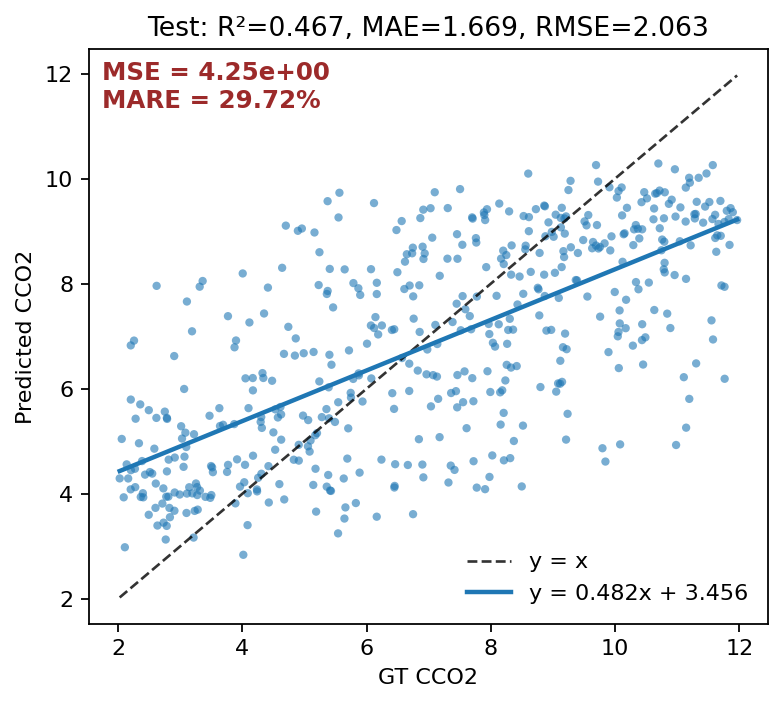

In [7]:
# =====================
# Load BEST & evaluate — bring y back to original units
# =====================
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import math
import tensorflow as tf
from tensorflow import keras

# Load without compile to avoid legacy alias issues, then (re)compile
best = keras.models.load_model(BEST_MODEL, compile=False)
best.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=tf.keras.losses.MeanSquaredError(name="mse"),
    metrics=[keras.metrics.MeanAbsoluteError(name="mae"),
             keras.metrics.RootMeanSquaredError(name="rmse")]
)

# Predict in normalized target space
pred_test_n = best.predict(X_test_n, verbose=0).ravel().astype(np.float64)

# ---- DENORMALIZE to original HHB2 units (y_mean, y_std from training) ----
pred_test = pred_test_n * float(y_std) + float(y_mean)

# Metrics in ORIGINAL units
mae  = mean_absolute_error(y_test, pred_test)
rmse = math.sqrt(mean_squared_error(y_test, pred_test))
r2   = r2_score(y_test, pred_test)

print("\n=== TEST METRICS (best checkpoint, original units) ===")
print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R^2 : {r2:.6f}")
print(f"Loaded best model → {BEST_MODEL}")

# ---- Plot GT vs Pred (original units) ----
mse  = mean_squared_error(y_test, pred_test)
mare = np.mean(np.abs((pred_test - y_test) / np.clip(np.abs(y_test), 1e-8, None))) * 100.0

plt.figure(figsize=(5, 4.5), dpi=160)
plt.scatter(y_test, pred_test, s=14, alpha=0.6, edgecolors='none')

lo = float(min(np.min(y_test), np.min(pred_test)))
hi = float(max(np.max(y_test), np.max(pred_test)))
if not (np.isfinite(lo) and np.isfinite(hi)) or lo == hi:
    lo, hi = -1.0, 1.0

# Identity line
plt.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.8, label='y = x')

# Best-fit line (guard against degenerate variance)
if np.std(y_test) > 0:
    a, b = np.polyfit(y_test, pred_test, 1)
    xx = np.linspace(lo, hi, 200)
    plt.plot(xx, a * xx + b, lw=2, label=f'y = {a:.3f}x + {b:.3f}')

plt.xlabel("GT CCO2")
plt.ylabel("Predicted CCO2")
plt.title(f"Test: R²={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")
plt.text(0.02, 0.98, f"MSE = {mse:.2e}\nMARE = {mare:.2f}%",
         transform=plt.gca().transAxes, va='top', ha='left',
         color='#9c2a2a', fontsize=11, fontweight='bold')
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()


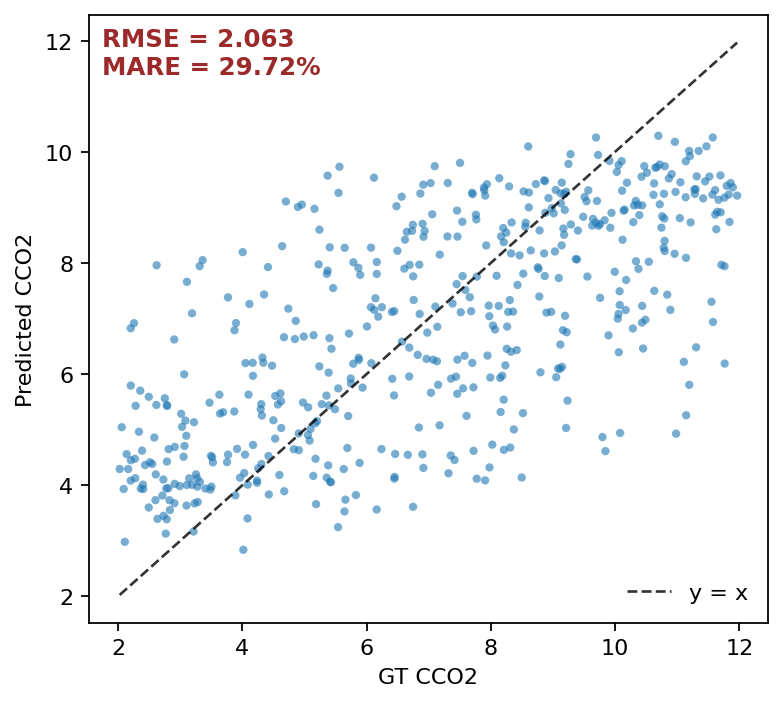

In [8]:
# ---- Plot GT vs Pred (original units) ----
mse  = mean_squared_error(y_test, pred_test)
rmse = float(np.sqrt(mse))  # root mean square error
mare = np.mean(np.abs((pred_test - y_test) / np.clip(np.abs(y_test), 1e-8, None))) * 100.0

plt.figure(figsize=(5, 4.5), dpi=160)
plt.scatter(y_test, pred_test, s=14, alpha=0.6, edgecolors='none')

lo = float(min(np.min(y_test), np.min(pred_test)))
hi = float(max(np.max(y_test), np.max(pred_test)))
if not (np.isfinite(lo) and np.isfinite(hi)) or lo == hi:
    lo, hi = -1.0, 1.0

# Identity line only
plt.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.8, label='y = x')

plt.xlabel("GT CCO2")
plt.ylabel("Predicted CCO2")

# Replace MSE with RMSE in the textbox
plt.text(0.02, 0.98, f"RMSE = {rmse:.3f}\nMARE = {mare:.2f}%",
         transform=plt.gca().transAxes, va='top', ha='left',
         color='#9c2a2a', fontsize=11, fontweight='bold')

plt.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()